In [1]:
from neuromaps import NeuroMapOriginal, NeuroMapTargetNormalized

model_original = NeuroMapOriginal.load("checkpoints/original/model.ckpt")
fixed_model = NeuroMapTargetNormalized.load("checkpoints/fixed/model.ckpt")

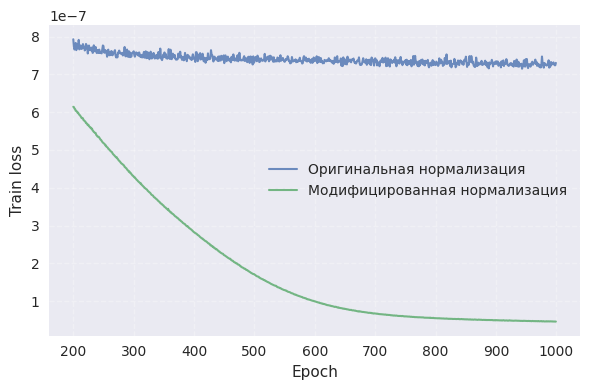

In [2]:
import matplotlib.pyplot as plt
import numpy as np

pass_first = 200
hist_o = model_original.training_history["train_loss"][pass_first:]
hist_f = fixed_model.training_history["train_loss"][pass_first:]

plt.style.use("seaborn-v0_8")
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

epochs_o = np.arange(pass_first, pass_first + len(hist_o))
epochs_f = np.arange(pass_first, pass_first + len(hist_f))

ax.plot(epochs_o, hist_o,
        label="Оригинальная нормализация", lw=1.5, alpha=.8)
ax.plot(epochs_f, hist_f,
        label="Модифицированная нормализация", lw=1.5, alpha=.8)

ax.set_xlabel("Epoch")
ax.set_ylabel("Train loss")
ax.legend()
ax.grid(True, ls="--", alpha=.3)
plt.tight_layout()
plt.show()

In [15]:
from utils import plot_compare_trajectories, get_attractor_trajectory
from systems import chua_rk4, chua_right_part

u0 = [-3.43086445, -1.78514213, -4.73140597]
p = [8.4, 12, 0, -0.12, -1.15]

nm_orig_traj = model_original.simulate(u0=u0, p=p, n_steps=20000, divergence_threshold=1e3)
nm_modf_traj = fixed_model.simulate(u0=u0, p=p, n_steps=20000, divergence_threshold=1e3)
ode_traj = get_attractor_trajectory(chua_rk4, chua_right_part, u0, p, 0.01, 50, 50, lambda x, y: x[1], lambda x, y: [0, 1], divergence_threshold=1e3)

if nm_orig_traj is not None:
    nm_orig_traj = nm_orig_traj[10000:]
if nm_modf_traj is not None:
    nm_modf_traj = nm_modf_traj[10000:]

plot_compare_trajectories(ode_traj, nm_orig_traj, nm_modf_traj, labels=['ODE', 'Оригинальное нейроотображение', 'Модифицированное нейроотображение'],
layout='sidebyside')

Симуляция:   0%|                                                         | 0/20000 [00:00<?, ?шаг/s]

2026-01-11 13:16:30 - neuromap_sync.nm_original - INFO - simulate:249 - Траектория разошлась (норма = 1.00e+03 > 1.00e+03)


Симуляция:  12%|█████                                      | 2329/20000 [00:00<00:01, 11654.17шаг/s]

2026-01-11 13:16:30 - neuromap_sync.nm_target_normalized - INFO - simulate:258 - Траектория разошлась (норма = 1.00e+03 > 1.00e+03)


Симуляция:  12%|█████                                      | 2353/20000 [00:00<00:01, 11352.39шаг/s]

2026-01-11 13:16:30 - neuromap_sync.plots - WARNING - plot_compare_trajectories:182 - Все траектории пустые или None


Симуляция: 100%|██████████████████████████████████████████| 20000/20000 [00:01<00:00, 11069.19шаг/s]


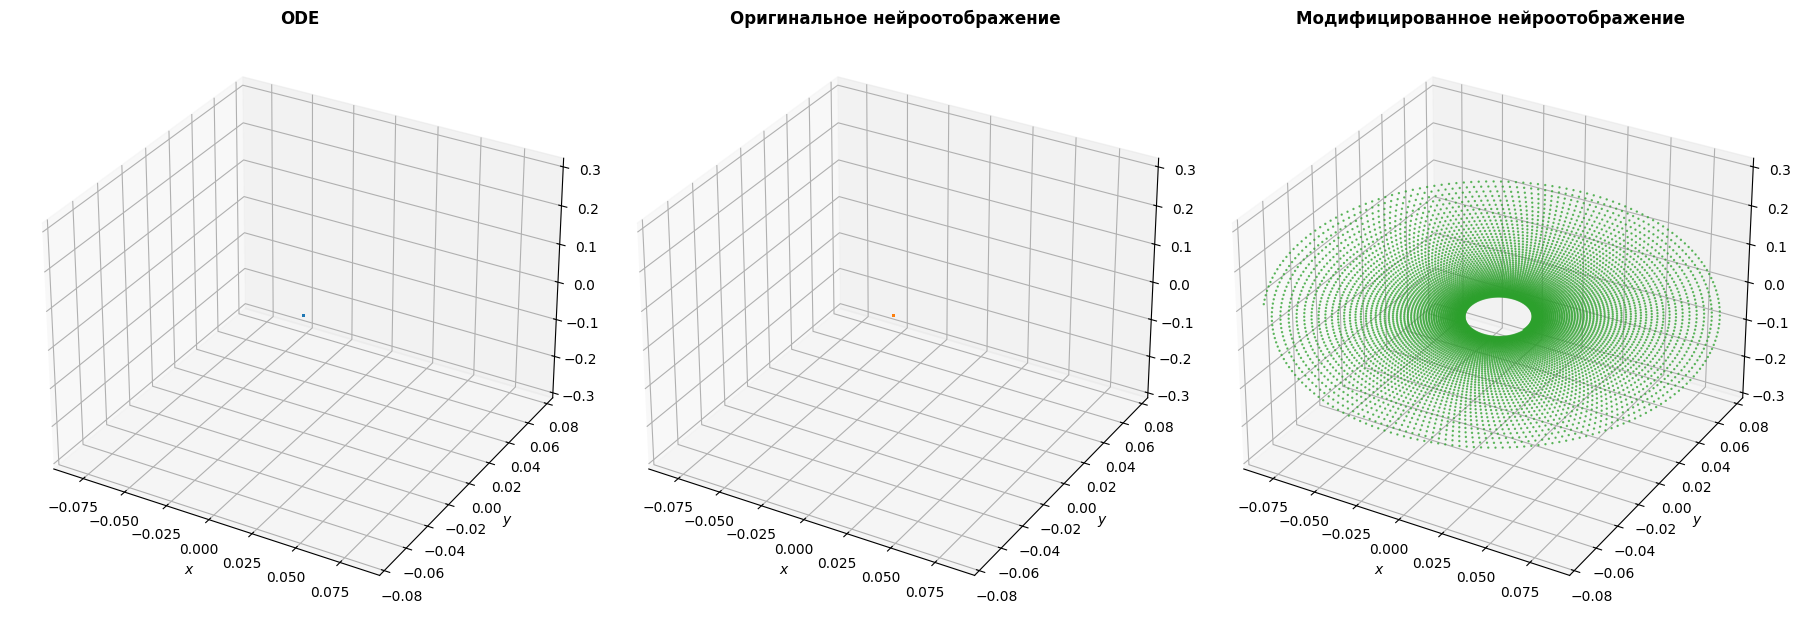

In [17]:
from utils import plot_compare_trajectories, get_attractor_trajectory
from systems import chua_rk4, chua_right_part

u0 = [-3.91055058, 1.14827257, 4.0497644]
p = [8.4, 12, 0, -0.12, -1.15]

nm_orig_traj = model_original.simulate(u0=u0, p=p, n_steps=20000, divergence_threshold=1e4)
nm_modf_traj = fixed_model.simulate(u0=u0, p=p, n_steps=20000, divergence_threshold=1e4)
ode_traj = get_attractor_trajectory(chua_rk4, chua_right_part, u0, p, 0.01, 300, 100, lambda x, y: x[1], lambda x, y: [0, 1, 0], divergence_threshold=1e4)

if nm_orig_traj is not None:
    nm_orig_traj = nm_orig_traj[10000:]
if nm_modf_traj is not None:
    nm_modf_traj = nm_modf_traj[10000:]

plot_compare_trajectories(ode_traj, nm_orig_traj, nm_modf_traj, labels=['ODE', 'Оригинальное нейроотображение', 'Модифицированное нейроотображение'],
layout='sidebyside')

Симуляция: 100%|███████████████████████████████████████████| 20000/20000 [00:02<00:00, 8952.28шаг/s]


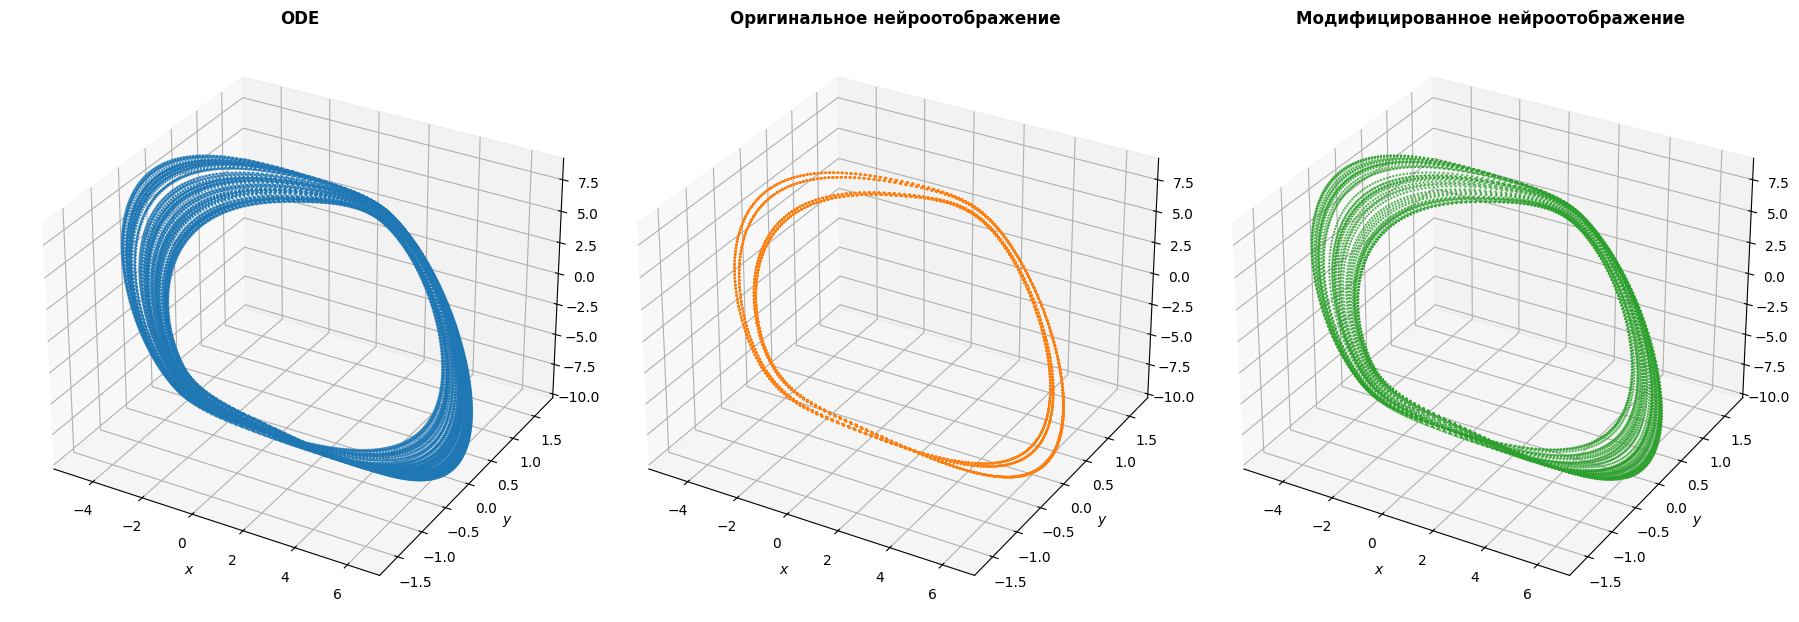

In [18]:
from utils import plot_compare_trajectories, get_attractor_trajectory
from systems import chua_rk4, chua_right_part

u0 = [-0.06298417, -1.53119096, 2.58772816]
p = [8.4, 12, 0, -0.12, -1.15]

nm_orig_traj1 = model_original.simulate(u0=u0, p=p, n_steps=20000, divergence_threshold=1e4)
nm_modf_traj1 = fixed_model.simulate(u0=u0, p=p, n_steps=20000, divergence_threshold=1e4)
ode_traj = get_attractor_trajectory(chua_rk4, chua_right_part, u0, p, 0.01, 100, 100, lambda x, y: x[1], lambda x, y: [0, 1, 0], divergence_threshold=1e4)

if nm_orig_traj1 is not None:
    nm_orig_traj1 = nm_orig_traj1[10000:]
if nm_modf_traj1 is not None:
    nm_modf_traj1 = nm_modf_traj1[10000:]

plot_compare_trajectories(ode_traj, nm_orig_traj1, nm_modf_traj1, labels=['ODE', 'Оригинальное нейроотображение', 'Модифицированное нейроотображение'],
layout='sidebyside')

Симуляция: 100%|██████████████████████████████████████████| 20000/20000 [00:01<00:00, 11156.42шаг/s]


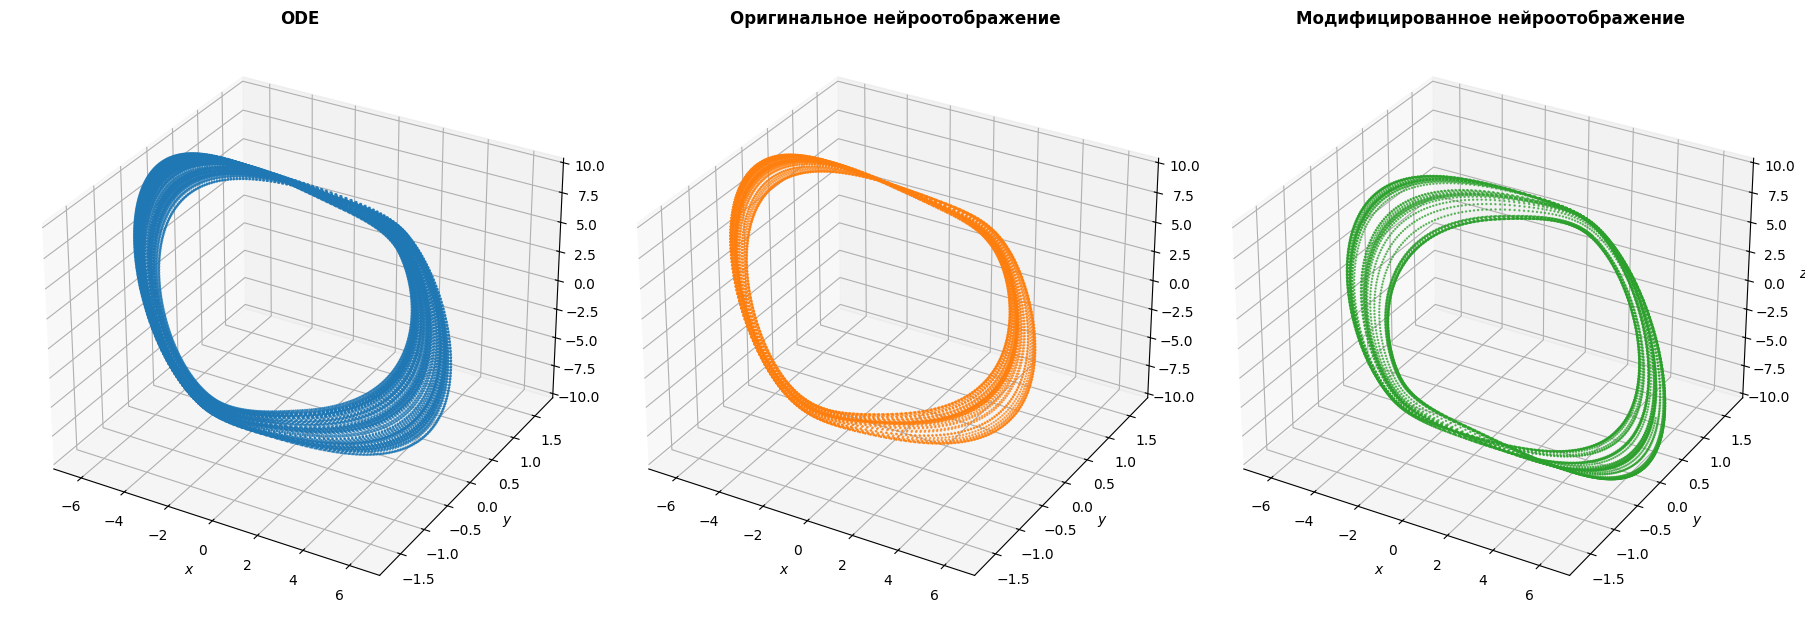

In [19]:
from utils import plot_compare_trajectories, get_attractor_trajectory
from systems import chua_rk4, chua_right_part

u0 = [ 2.98994669e+00, 4.49008896e-04, -4.52306348e+00]
p = [8.4, 12, 0, -0.12, -1.15]

nm_orig_traj2 = model_original.simulate(u0=u0, p=p, n_steps=20000, divergence_threshold=1e4)
nm_modf_traj2 = fixed_model.simulate(u0=u0, p=p, n_steps=20000, divergence_threshold=1e4)
ode_traj = get_attractor_trajectory(chua_rk4, chua_right_part, u0, p, 0.01, 300, 100, lambda x, y: x[1], lambda x, y: [0, 1, 0], divergence_threshold=1e4)

if nm_orig_traj2 is not None:
    nm_orig_traj2 = nm_orig_traj2[10000:]
if nm_modf_traj2 is not None:
    nm_modf_traj2 = nm_modf_traj2[10000:]

plot_compare_trajectories(ode_traj, nm_orig_traj2, nm_modf_traj2,
    labels=['ODE', 'Оригинальное нейроотображение', 'Модифицированное нейроотображение'],
    layout='sidebyside')

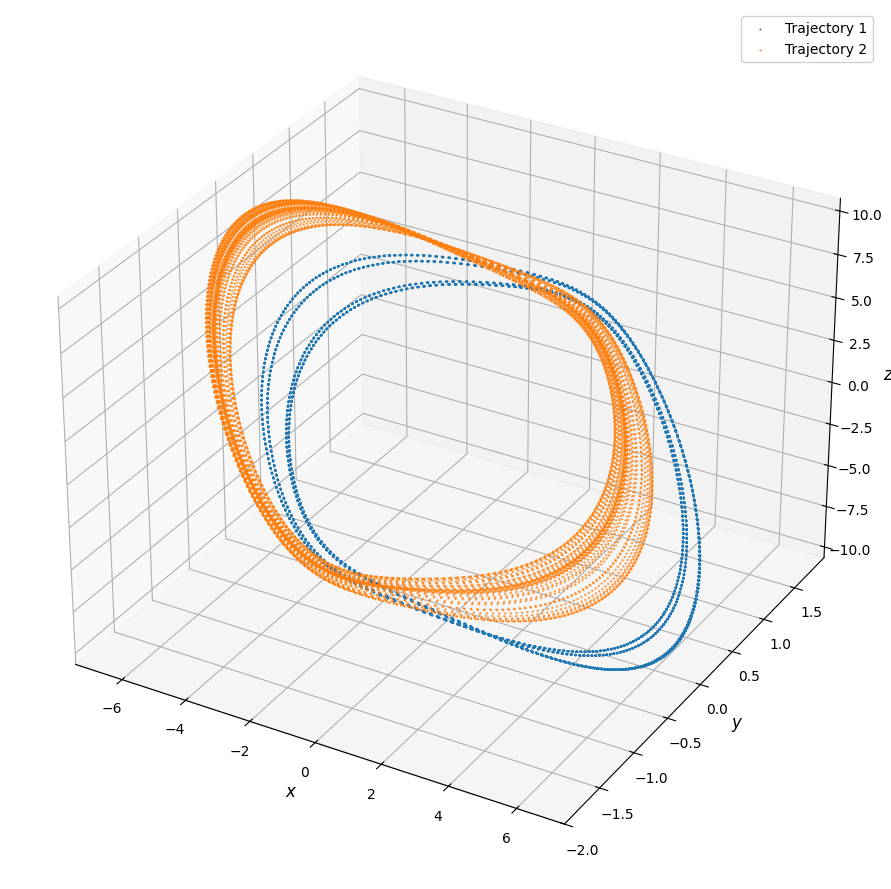

In [21]:
plot_compare_trajectories(nm_orig_traj1, nm_orig_traj2)